2026-05-25 02:30:56.842237: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779676257.083265      56 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779676257.145622      56 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779676257.685973      56 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779676257.686014      56 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779676257.686018      56 computation_placer.cc:177] computation placer alr

  Підготовка середовища Kaggle: Завантаження зображень та моделі...
[ІНФО] Завантаження baboon.png...
[ІНФО] Завантаження lake_house.png...
[ІНФО] Завантаження anime_person.png...
[ІНФО] Завантаження моделі ESRGAN з TF-Hub (це може зайняти хвилину)...


2026-05-25 02:31:24.573557: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


[УСПІХ] Модель завантажено!

--- Обробка зображення: baboon.png ---
Вхідний розмір: (1, 240, 168, 3)
Вихідний розмір: (960, 672, 3)
Збережено покращене зображення: ./lab07/enhanced/enhanced_baboon.png

--- Обробка зображення: lake_house.png ---
Вхідний розмір: (1, 168, 248, 3)
Вихідний розмір: (672, 992, 3)
Збережено покращене зображення: ./lab07/enhanced/enhanced_lake_house.png

--- Обробка зображення: anime_person.png ---
Вхідний розмір: (1, 128, 128, 3)
Вихідний розмір: (512, 512, 3)
Збережено покращене зображення: ./lab07/enhanced/enhanced_anime_person.png

  ВІДОБРАЖЕННЯ ЗАГАЛЬНОЇ СІТКИ ЗОБРАЖЕНЬ


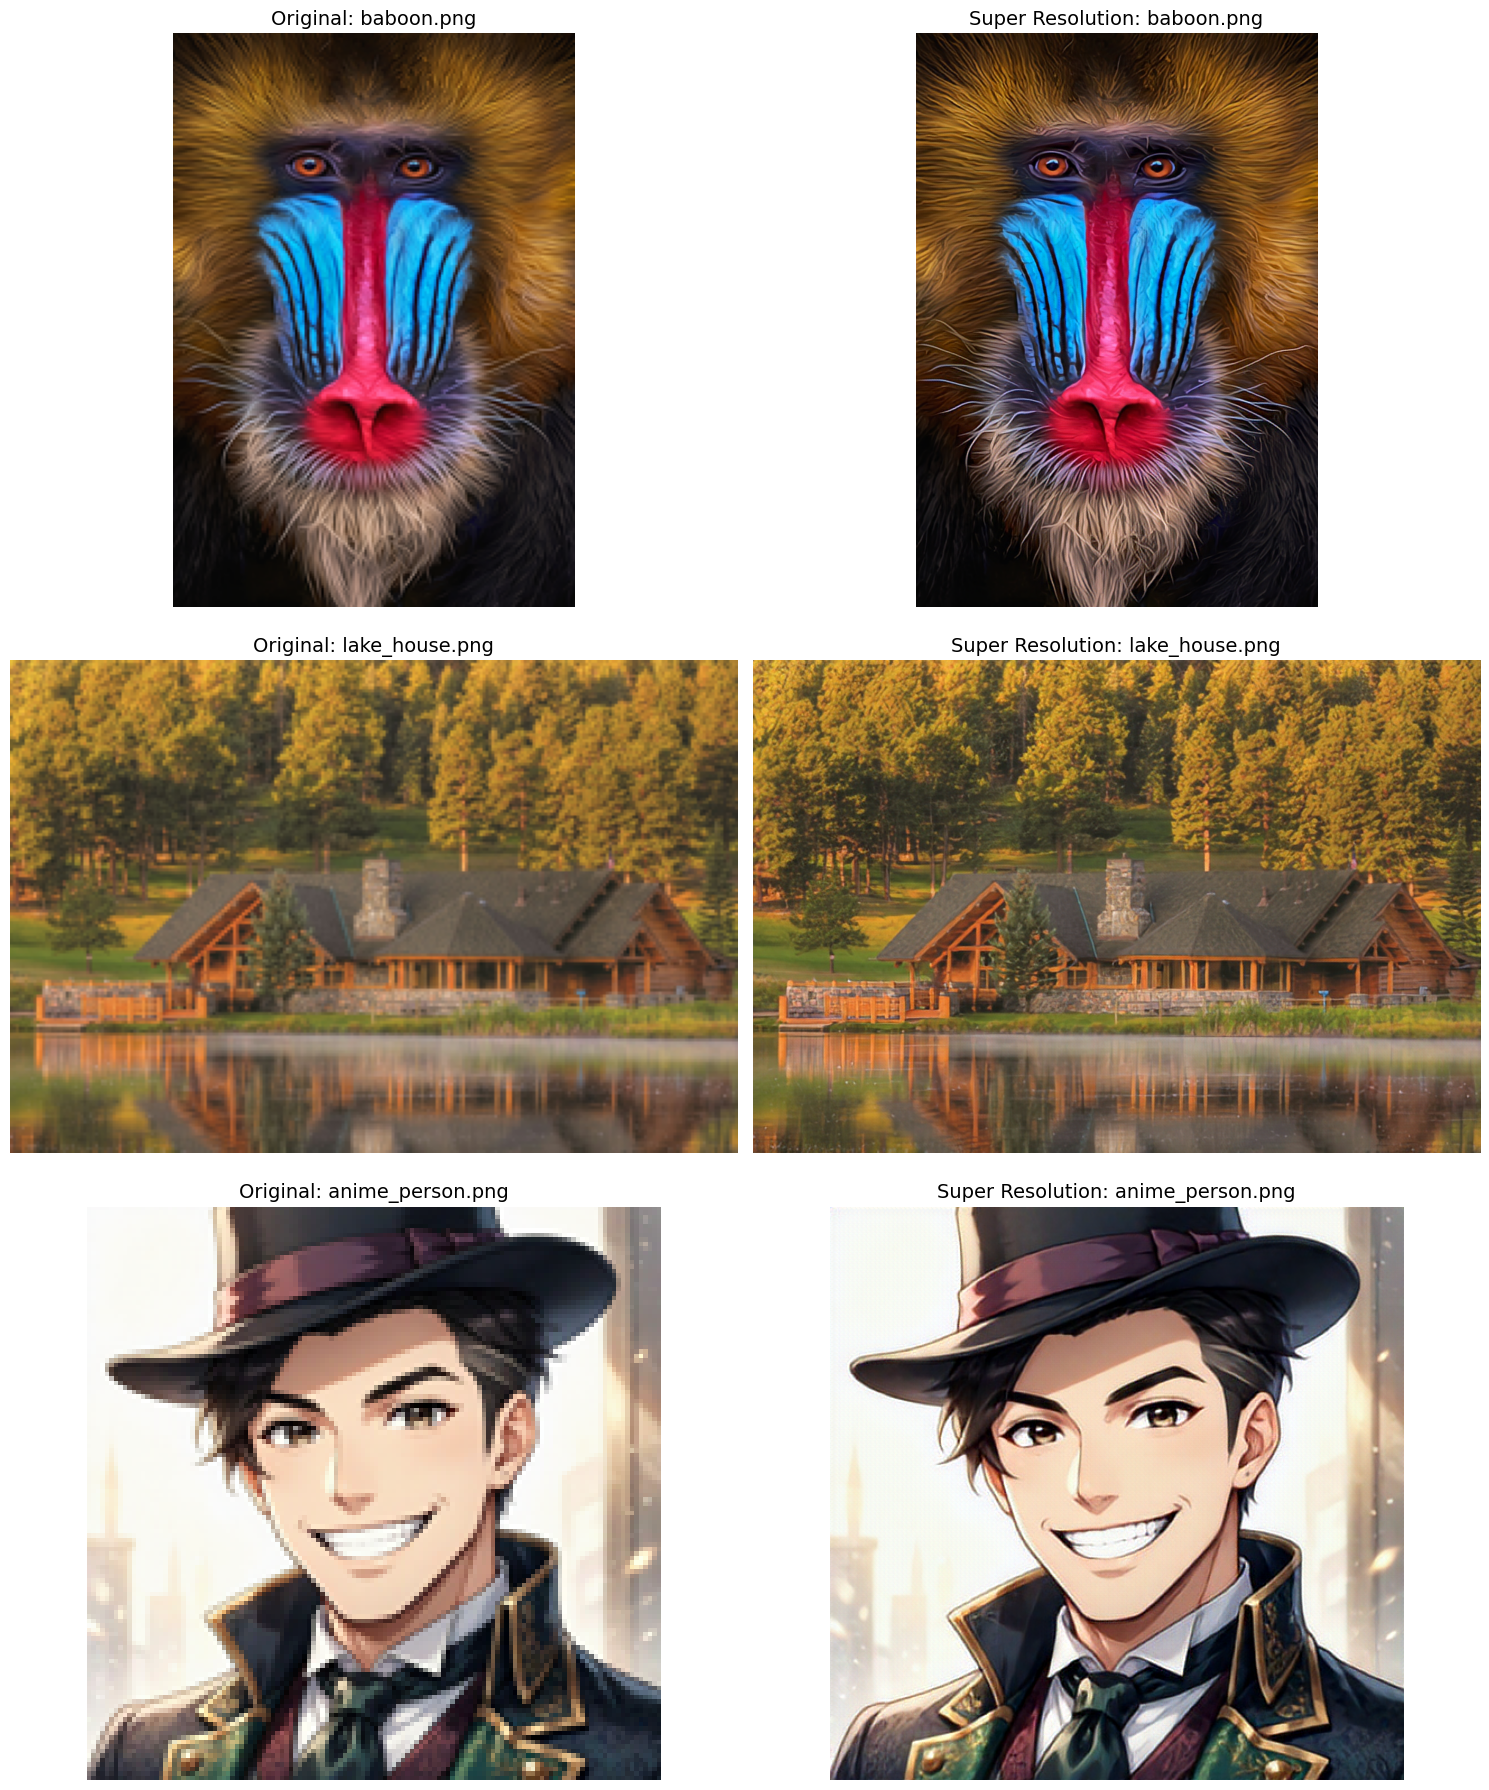


  ВІДОБРАЖЕННЯ КОЖНОГО ЗОБРАЖЕННЯ ОКРЕМО


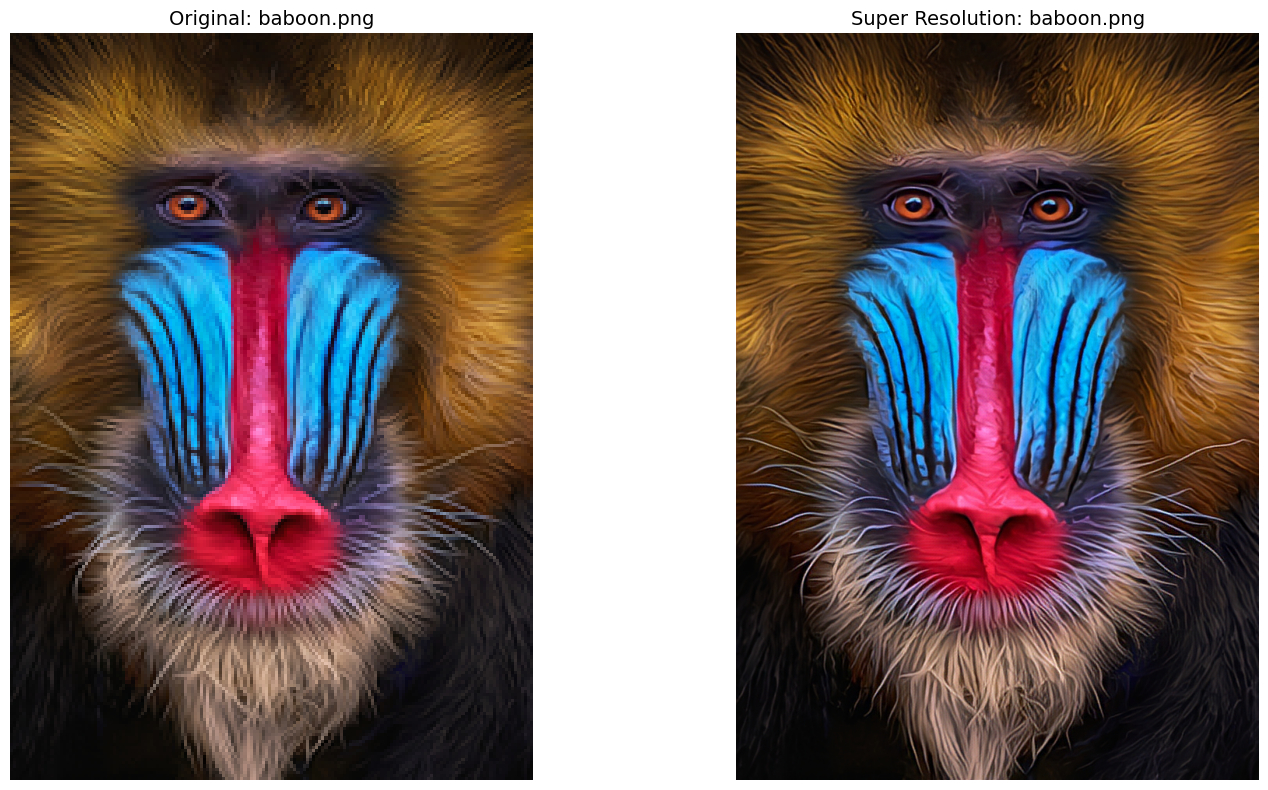

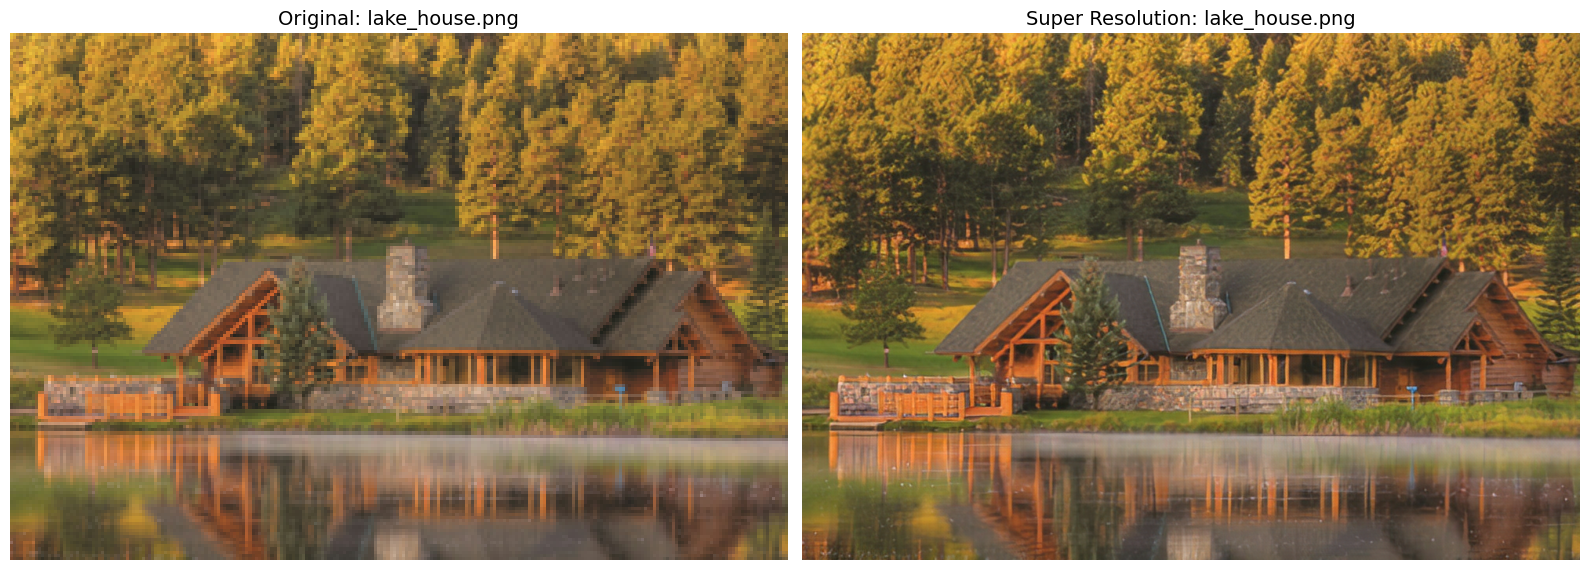

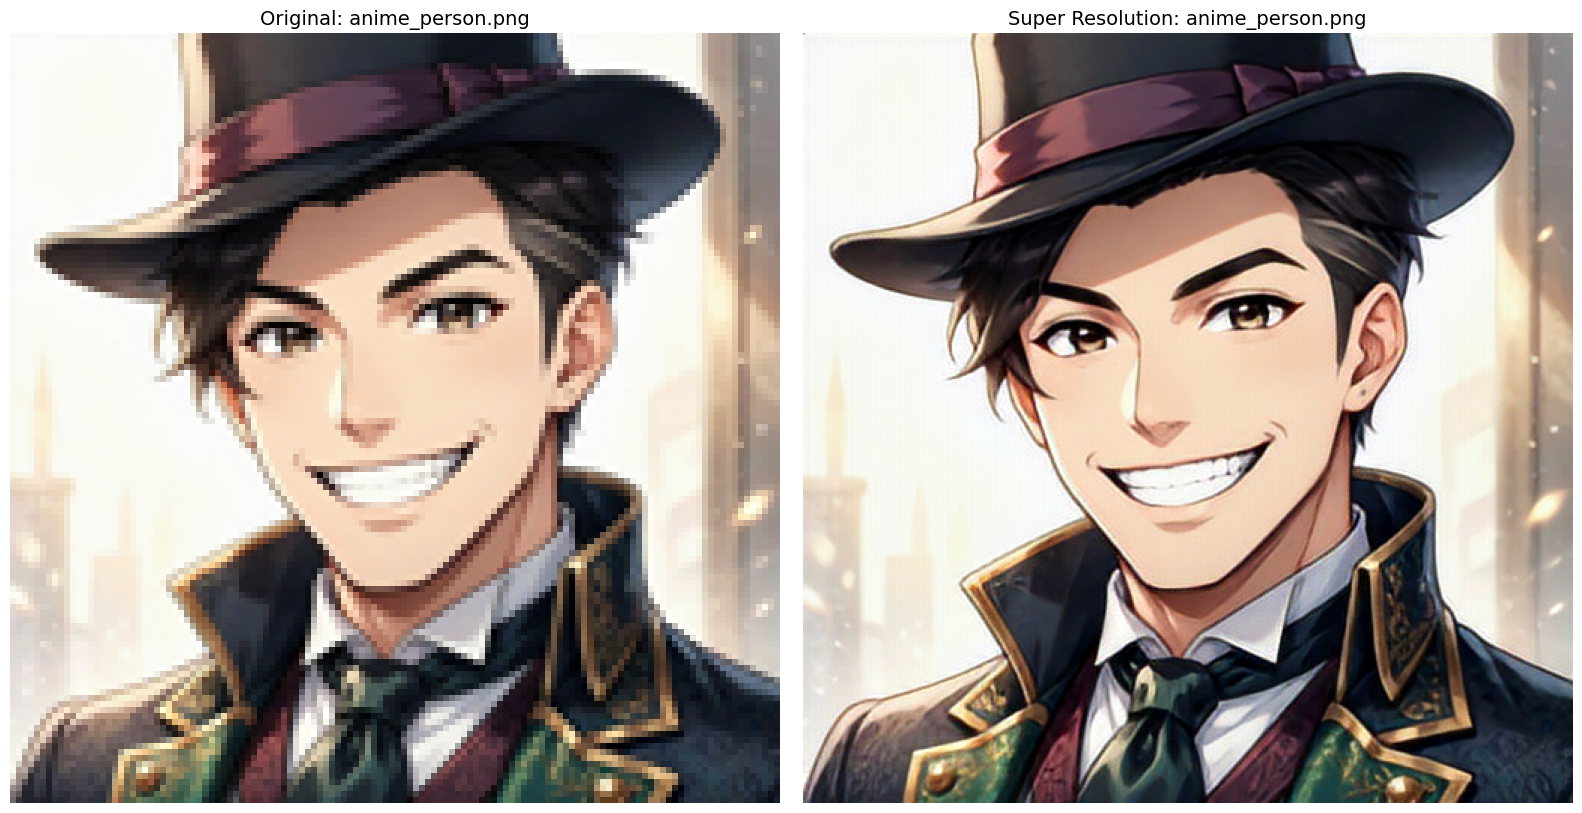

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
from PIL import Image
import urllib.request

# ==============================================================================
# ПІДГОТОВКА СЕРЕДОВИЩА ТА ЗАВАНТАЖЕННЯ ДАНИХ
# ==============================================================================
print("=" * 70)
print("  Підготовка середовища Kaggle: Завантаження зображень та моделі...")
print("=" * 70)

LAB_PATH = "./lab07/"
os.makedirs(LAB_PATH, exist_ok=True)

# Завантаження зображень з GitHub (використовуємо 'raw' посилання)
files_to_download = {
    "baboon.png": "https://raw.githubusercontent.com/YuHryshchenko/zpi-zp41_ai_image_processing_HryshchenkoYuliia_KPI_2026/main/lab07/baboon.png",
    "lake_house.png": "https://raw.githubusercontent.com/YuHryshchenko/zpi-zp41_ai_image_processing_HryshchenkoYuliia_KPI_2026/main/lab07/lake_house.png",
    "anime_person.png": "https://raw.githubusercontent.com/YuHryshchenko/zpi-zp41_ai_image_processing_HryshchenkoYuliia_KPI_2026/main/lab07/anime_person.png"
}

for filename, url in files_to_download.items():
    filepath = os.path.join(LAB_PATH, filename)
    if not os.path.exists(filepath):
        print(f"[ІНФО] Завантаження {filename}...")
        urllib.request.urlretrieve(url, filepath)

# Завантаження попередньо навченої моделі ESRGAN
model_url = "https://tfhub.dev/captain-pool/esrgan-tf2/1"
print("[ІНФО] Завантаження моделі ESRGAN з TF-Hub (це може зайняти хвилину)...")
model = hub.load(model_url)
print("[УСПІХ] Модель завантажено!\n")

# ==============================================================================
# ФУНКЦІЇ ОБРОБКИ ТА ВІДОБРАЖЕННЯ
# ==============================================================================

# Допоміжна функція для конвертації тензора у PIL Image (щоб зберігати та малювати)
def get_pil_image(image):
    image = np.asarray(image)
    image = tf.clip_by_value(image, 0, 255)
    return Image.fromarray(tf.cast(image, tf.uint8).numpy())

# ── Функція plot_image - вивід зображень (адаптовано для сітки) ────────────
def plot_image(image, title="", ax=None):
    pil_img = get_pil_image(image)
    if ax is None:
        plt.imshow(pil_img)
        plt.axis("off")
        plt.title(title, fontsize=14)
    else:
        ax.imshow(pil_img)
        ax.axis("off")
        ax.set_title(title, fontsize=14)

# ── Функція process_image - обробка зображень ──────────────────────────────
def process_image(directory_path, image_name):
    print(f"--- Обробка зображення: {image_name} ---")
    
    # ── Зчитування вхідного зображення ─────────────────────────────────────
    original_image = tf.image.decode_image(tf.io.read_file(os.path.join(directory_path, image_name)))
    
    # Видаляємо alpha-канал
    if original_image.shape[-1] == 4:
        original_image = original_image[..., :-1]

    # ── Підготовка зображення для моделі ───────────────────────────────────
    hr_size = (tf.convert_to_tensor(original_image.shape[:-1]) // 4) * 4
    original_image = tf.image.crop_to_bounding_box(original_image, 0, 0, hr_size[0], hr_size[1])
    original_image = tf.cast(original_image, tf.float32)
    original_image = tf.expand_dims(original_image, 0)

    # ── Покращення зображення за допомогою моделі ──────────────────────────
    enhanced_image = model(original_image)
    enhanced_image = tf.squeeze(enhanced_image)
    original_squeeze = tf.squeeze(original_image)

    print(f"Вхідний розмір: {original_image.shape}")
    print(f"Вихідний розмір: {enhanced_image.shape}")

    # Зберігаємо результат локально на Kaggle
    enhanced_dir = os.path.join(directory_path, "enhanced")
    os.makedirs(enhanced_dir, exist_ok=True)
    save_path = os.path.join(enhanced_dir, f"enhanced_{image_name}")
    get_pil_image(enhanced_image).save(save_path)
    print(f"Збережено покращене зображення: {save_path}\n")

    # Повертаємо тензори для подальшого виводу
    return original_squeeze, enhanced_image

# ==============================================================================
# ВИКОНАННЯ ТА ВІЗУАЛІЗАЦІЯ
# ==============================================================================

# Список зображень для обробки
images_to_process = ["baboon.png", "lake_house.png", "anime_person.png"]
results = []

# Обробляємо всі зображення та зберігаємо тензори
for img_name in images_to_process:
    orig, enh = process_image(LAB_PATH, img_name)
    results.append((img_name, orig, enh))

# ── 1. Відображення загальної сітки (Big Grid) ─────────────────────────────
print("=" * 70)
print("  ВІДОБРАЖЕННЯ ЗАГАЛЬНОЇ СІТКИ ЗОБРАЖЕНЬ")
print("=" * 70)

# Створюємо сітку: кількість рядків = кількість зображень, 2 колонки
fig, axes = plt.subplots(len(results), 2, figsize=(15, 6 * len(results)))

for i, (name, orig, enh) in enumerate(results):
    plot_image(orig, title=f"Original: {name}", ax=axes[i, 0])
    plot_image(enh, title=f"Super Resolution: {name}", ax=axes[i, 1])

fig.tight_layout()
plt.show()

# ── 2. Відображення кожного зображення окремо (Separate) ───────────────────
print("\n" + "=" * 70)
print("  ВІДОБРАЖЕННЯ КОЖНОГО ЗОБРАЖЕННЯ ОКРЕМО")
print("=" * 70)

for name, orig, enh in results:
    plt.figure(figsize=(16, 8))
    
    # Оригінал
    plt.subplot(1, 2, 1)
    plot_image(orig, title=f"Original: {name}")
    
    # Super Resolution
    plt.subplot(1, 2, 2)
    plot_image(enh, title=f"Super Resolution: {name}")
    
    plt.tight_layout()
    plt.show()
